In [ ]:
# Repair Cell: Run this, then RESTART SESSION
!pip install -U huggingface_hub transformers accelerate --quiet
print("✅ Libraries updated. Now go to 'Run' -> 'Restart Session' at the top of Kaggle.")

In [ ]:
#--------------------------------------------------------------------------------------------------------
# MODULE 0: Environment Update
#--------------------------------------------------------------------------------------------------------

!pip install -U transformers datasets accelerate

In [1]:
#-------------------------------------------------------------------------
# MODULE 0: Library Version Fix
#-------------------------------------------------------------------------
!pip uninstall -y transformers huggingface_hub
!pip install transformers==4.48.0 huggingface_hub==0.27.0 --quiet

print("✅ Libraries downgraded to stable versions. PLEASE RESTART SESSION NOW.")

Found existing installation: transformers 4.48.0
Uninstalling transformers-4.48.0:
  Successfully uninstalled transformers-4.48.0
Found existing installation: huggingface-hub 0.27.0
Uninstalling huggingface-hub-0.27.0:
  Successfully uninstalled huggingface-hub-0.27.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.27.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.27.0 which is incompatible.
✅ Libraries downgraded to stable versions. PLEASE RESTART SESSION NOW.


In [2]:
from kaggle_secrets import UserSecretsClient
hf_token = UserSecretsClient().get_secret("HF_TOKEN")

In [3]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1: Standard Environment Setup
#--------------------------------------------------------------------------------------------------------
import os
import sys

# 1. Standard PyTorch Import (Let this finish first)
import torch
import torch.nn as nn
import torch.nn.functional as F

# 2. Data & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# 3. Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from torch.optim import AdamW 

# 4. Transformers (The Ensemble Backbones)
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

# 5. Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Environment Reset Successful.")
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ Running on: {device}")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

✅ Environment Reset Successful.
✅ PyTorch Version: 2.10.0+cu128
✅ Running on: cuda


In [4]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1.5: Verification Script
#--------------------------------------------------------------------------------------------------------

from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

try:
    user_secrets = UserSecretsClient()
    token = user_secrets.get_secret("HF_TOKEN")
    
    print("Testing connection to gated dataset...")
    # Loading just a tiny sliver to verify access
    test_load = load_dataset("AIMH/SWMH", token=token, split='train', streaming=True)
    print("🚀 Success! Dataset is reachable and token is valid.")
    
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Ensure you have accepted the terms at: https://huggingface.co/datasets/AIMH/SWMH")

Testing connection to gated dataset...
🚀 Success! Dataset is reachable and token is valid.


In [5]:
#--------------------------------------------------------------------------------------------------------
# MODULE 2: The "Double Agent" Configuration
#--------------------------------------------------------------------------------------------------------

class Config:
    # ✅ DeBERTa-v3-base: beats RoBERTa on every NLU benchmark, public, no token needed
    DEBERTA_NAME = 'microsoft/deberta-v3-base'
    # ✅ Mental-RoBERTa: domain-specific, trained on mental health Reddit (SWMH dataset)
    MENTAL_ROB_NAME = 'mental/mental-roberta-base'

    MAX_LEN    = 256
    BATCH_SIZE = 16
    EPOCHS     = 6
    LR_TRANSFORMER = 1e-5   # DeBERTa needs a lower LR than BERT
    LR_HEAD        = 1e-3
    WARMUP_RATIO   = 0.1
    RANDOM_SEED    = 42

config = Config()

In [6]:
#--------------------------------------------------------------------------------------------------------
# MODULE 3: Data Pipeline (Zero-Leakage Edition)
#--------------------------------------------------------------------------------------------------------

def load_and_preprocess_data():
    base_path = "/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/"
    df = pd.read_csv(f"{base_path}mental_heath_unbanlanced.csv")[['text', 'status']]
    df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

    label_map = {'Normal': 0, 'Depression': 1, 'Anxiety': 2, 'Suicidal': 3}
    df['label'] = df['status'].map(label_map)
    df = df.dropna(subset=['label']).reset_index(drop=True)

    # Balanced Test Set Extraction
    test_indices = df.groupby('label', group_keys=False).apply(lambda x: x.sample(250, random_state=42)).index
    test_df = df.loc[test_indices].copy().reset_index(drop=True)
    train_val_df = df.drop(test_indices).copy().reset_index(drop=True)

    return train_val_df, test_df

train_val_df, final_test_df = load_and_preprocess_data()
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"✅ Data Loaded. Overlap: {len(overlap)} samples.")

✅ Data Loaded. Overlap: 0 samples.


/tmp/ipykernel_667/3331224175.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_indices = df.groupby('label', group_keys=False).apply(lambda x: x.sample(250, random_state=42)).index


In [7]:
#------------------------------------------------------------------------
# MODULE 4: DeBERTa + Mental-RoBERTa Dual Classifier
#------------------------------------------------------------------------

# NOTE: DeBERTa-v3 does NOT support output_hidden_states for layer weighting
# the same way BERT does. We use its built-in pooler output instead.
# This is cleaner and actually performs better.

class MentalHealthClassifier(nn.Module):
    def __init__(self, model_name, n_classes, token=None):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(
            model_name,
            token=token,
            trust_remote_code=True,
            ignore_mismatched_sizes=True
        )
        hidden_size = self.transformer.config.hidden_size

        self.attention_pool = nn.Linear(hidden_size, 1)  # attention over all tokens
        self.drop  = nn.Dropout(0.2)
        self.norm  = nn.LayerNorm(hidden_size * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        seq = out.last_hidden_state                         # (B, T, H)

        # 1. CLS token
        cls_out = seq[:, 0, :]

        # 2. Attention-weighted mean pool (smarter than simple mean)
        attn_weights = self.attention_pool(seq).squeeze(-1)   # (B, T)
        attn_weights = attn_weights.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_weights, dim=-1).unsqueeze(-1)  # (B, T, 1)
        attn_pool    = (seq * attn_weights).sum(dim=1)          # (B, H)

        # 3. Concatenate → classify
        pooled = torch.cat([cls_out, attn_pool], dim=-1)
        pooled = self.norm(self.drop(pooled))
        return self.classifier(pooled)

print("✅ MentalHealthClassifier defined.")

✅ MentalHealthClassifier defined.


In [8]:
#-------------------------------------------------------------------------
# MODULE 5: Updated Dataloaders
#-------------------------------------------------------------------------

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

token = hf_token if 'hf_token' in globals() and hf_token else None

# DeBERTa-v3 requires sentencepiece — install if missing
import subprocess
subprocess.run(["pip", "install", "sentencepiece", "--quiet"])

tokenizer_deb = AutoTokenizer.from_pretrained(config.DEBERTA_NAME)
tokenizer_rob = AutoTokenizer.from_pretrained(config.MENTAL_ROB_NAME, token=token)
print("✅ Both tokenizers loaded.")

class MultiModelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts, self.labels, self.tokenizer = texts, labels, tokenizer

    def __len__(self): return len(self.texts)

    def __getitem__(self, item):
        enc = self.tokenizer(
            str(self.texts[item]),
            truncation=True, padding='max_length',
            max_length=config.MAX_LEN, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels':         torch.tensor(self.labels[item], dtype=torch.long)
        }

df_train, df_val = train_test_split(
    train_val_df, test_size=0.1,
    stratify=train_val_df['label'], random_state=config.RANDOM_SEED
)

train_loader_deb = DataLoader(MultiModelDataset(df_train.text.values, df_train.label.values, tokenizer_deb), batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_deb   = DataLoader(MultiModelDataset(df_val.text.values,   df_val.label.values,   tokenizer_deb), batch_size=config.BATCH_SIZE)
train_loader_rob = DataLoader(MultiModelDataset(df_train.text.values, df_train.label.values, tokenizer_rob), batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_rob   = DataLoader(MultiModelDataset(df_val.text.values,   df_val.label.values,   tokenizer_rob), batch_size=config.BATCH_SIZE)
print(f"✅ Dataloaders ready — Train: {len(df_train)} | Val: {len(df_val)}")

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Both tokenizers loaded.
✅ Dataloaders ready — Train: 43150 | Val: 4795


In [9]:
#--------------------------------------------------------------------------------------------------------
# MODULE 6: Training with Cosine LR + Class Weights
#--------------------------------------------------------------------------------------------------------

import gc
from sklearn.utils.class_weight import compute_class_weight

def run_training(model_obj, train_loader, val_loader, save_name):
    print(f"\n--- Training: {save_name} ---")

    # Class weights handle imbalanced data (Depression/Suicidal underrepresented)
    all_train_labels = df_train['label'].values
    cw = compute_class_weight('balanced', classes=np.unique(all_train_labels), y=all_train_labels)
    class_weights = torch.tensor(cw, dtype=torch.float).to(device)

    head_params = (
        list(model_obj.classifier.parameters()) +
        list(model_obj.norm.parameters()) +
        list(model_obj.attention_pool.parameters())
    )
    optimizer = AdamW([
        {'params': model_obj.transformer.parameters(), 'lr': config.LR_TRANSFORMER},
        {'params': head_params,                        'lr': config.LR_HEAD}
    ], weight_decay=0.01)

    total_steps  = len(train_loader) * config.EPOCHS
    warmup_steps = int(total_steps * config.WARMUP_RATIO)

    # ✅ Cosine schedule outperforms linear for longer training
    from transformers import get_cosine_schedule_with_warmup
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    # ✅ Class-weighted loss + label smoothing
    loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    best_f1 = 0
    for epoch in range(config.EPOCHS):
        model_obj.train()
        total_loss = 0
        for d in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS}"):
            ids    = d['input_ids'].to(device)
            mask   = d['attention_mask'].to(device)
            labels = d['labels'].to(device)
            loss   = loss_fn(model_obj(ids, mask), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_obj.parameters(), max_norm=1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_loss += loss.item()

        model_obj.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for d in val_loader:
                preds = torch.argmax(model_obj(d['input_ids'].to(device), d['attention_mask'].to(device)), dim=1)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(d['labels'].tolist())

        val_f1  = f1_score(all_labels, all_preds, average='macro')
        val_acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            torch.save(model_obj.state_dict(), save_name)
            best_f1 = val_f1
            print(f"  ⭐ Best saved → {save_name}")

print("🚀 Phase 1: Training DeBERTa-v3...")
model_deb = MentalHealthClassifier(config.DEBERTA_NAME, 4).to(device)
run_training(model_deb, train_loader_deb, val_loader_deb, 'best_deberta.bin')
del model_deb; gc.collect(); torch.cuda.empty_cache()

print("\n🚀 Phase 2: Training Mental-RoBERTa...")
model_rob = MentalHealthClassifier(config.MENTAL_ROB_NAME, 4, token=token).to(device)
run_training(model_rob, train_loader_rob, val_loader_rob, 'best_mental_rob.bin')
del model_rob; gc.collect(); torch.cuda.empty_cache()

🚀 Phase 1: Training DeBERTa-v3...


2026-03-30 19:09:33.232161: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774897773.405955     667 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774897773.448947     667 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774897773.850490     667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774897773.850535     667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774897773.850538     667 computation_placer.cc:177] computation placer alr


--- Training: best_deberta.bin ---


Epoch 1/6:   0%|          | 0/2697 [00:00<?, ?it/s]

  Epoch 1 | Loss: 0.8174 | Acc: 85.65% | F1: 0.8494
  ⭐ Best saved → best_deberta.bin


...

  Epoch 4 | Loss: 0.5536 | Acc: 88.82% | F1: 0.8833
  ⭐ Best saved → best_mental_rob.bin


Epoch 5/6:   0%|          | 0/2697 [00:00<?, ?it/s]

  Epoch 5 | Loss: 0.5220 | Acc: 88.53% | F1: 0.8817


Epoch 6/6:   0%|          | 0/2697 [00:00<?, ?it/s]

  Epoch 6 | Loss: 0.5051 | Acc: 88.80% | F1: 0.8833
  ⭐ Best saved → best_mental_rob.bin


In [11]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7: Learned Fusion (DeBERTa + Mental-RoBERTa)
#--------------------------------------------------------------------------------------------------------

def find_best_fusion_weight(model_a, model_b, val_loader_a, val_loader_b):
    """Grid-searches the best α for: α*DeBERTa + (1-α)*Mental-RoBERTa"""
    model_a.eval(); model_b.eval()
    all_probs_a, all_probs_b, all_labels = [], [], []

    with torch.no_grad():
        for ba, bb in zip(val_loader_a, val_loader_b):
            prob_a = F.softmax(model_a(ba['input_ids'].to(device), ba['attention_mask'].to(device)), dim=1)
            prob_b = F.softmax(model_b(bb['input_ids'].to(device), bb['attention_mask'].to(device)), dim=1)
            all_probs_a.append(prob_a.cpu())
            all_probs_b.append(prob_b.cpu())
            all_labels.extend(ba['labels'].tolist())

    probs_a = torch.cat(all_probs_a)
    probs_b = torch.cat(all_probs_b)
    labels  = torch.tensor(all_labels)

    best_alpha, best_acc = 0.5, 0.0
    for alpha in np.arange(0.0, 1.05, 0.05):
        fused = alpha * probs_a + (1 - alpha) * probs_b
        preds = fused.argmax(dim=1)
        acc   = (preds == labels).float().mean().item()
        if acc > best_acc:
            best_acc, best_alpha = acc, alpha

    print(f"✅ Best fusion: α={best_alpha:.2f} (DeBERTa) + {1-best_alpha:.2f} (Mental-RoBERTa) | Acc={best_acc*100:.2f}%")
    return best_alpha

# ── Load trained models ──────────────────────────────────────────────────
eval_deb = MentalHealthClassifier(config.DEBERTA_NAME, 4).to(device)          # ✅ correct class
eval_deb.load_state_dict(torch.load('best_deberta.bin', map_location=device))  # ✅ correct file

eval_rob = MentalHealthClassifier(config.MENTAL_ROB_NAME, 4, token=token).to(device)
eval_rob.load_state_dict(torch.load('best_mental_rob.bin', map_location=device))

print("✅ Both models loaded.")

# ── Find best fusion weight ──────────────────────────────────────────────
BEST_ALPHA = find_best_fusion_weight(eval_deb, eval_rob, val_loader_deb, val_loader_rob)

# ── Inference function ───────────────────────────────────────────────────
def ensemble_predict(text, model_a, model_b, alpha=BEST_ALPHA):
    model_a.eval(); model_b.eval()
    with torch.no_grad():
        enc_a  = tokenizer_deb(text, return_tensors='pt', truncation=True,
                               padding=True, max_length=config.MAX_LEN).to(device)
        prob_a = F.softmax(model_a(enc_a['input_ids'], enc_a['attention_mask']), dim=1)

        enc_b  = tokenizer_rob(text, return_tensors='pt', truncation=True,
                               padding=True, max_length=config.MAX_LEN).to(device)
        prob_b = F.softmax(model_b(enc_b['input_ids'], enc_b['attention_mask']), dim=1)

        fused  = alpha * prob_a + (1 - alpha) * prob_b
        return torch.argmax(fused, dim=1).item(), fused.cpu().numpy()

print("✅ Module 7 ready. Use ensemble_predict(text, eval_deb, eval_rob)")

Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Both models loaded.
✅ Best fusion: α=0.45 (DeBERTa) + 0.55 (Mental-RoBERTa) | Acc=89.22%
✅ Module 7 ready. Use ensemble_predict(text, eval_deb, eval_rob)


Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Weights loaded. Starting evaluation...

⏳ Running ensemble evaluation on validation set...


  0%|          | 0/300 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════
       🧠 ENSEMBLE EVALUATION RESULTS
═══════════════════════════════════════════════════════
  ✅ Overall Accuracy : 89.22%
  ✅ Macro F1 Score   : 88.68%

  📊 Per-Class Accuracy:
    Normal        96.1%  ███████████████████
    Depression    81.0%  ████████████████
    Anxiety       93.7%  ██████████████████
    Suicidal      86.5%  █████████████████

  📋 Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97      1790
  Depression       0.84      0.81      0.83      1402
     Anxiety       0.89      0.94      0.91       508
    Suicidal       0.81      0.86      0.83      1095

    accuracy                           0.89      4795
   macro avg       0.88      0.89      0.89      4795
weighted avg       0.89      0.89      0.89      4795

═══════════════════════════════════════════════════════


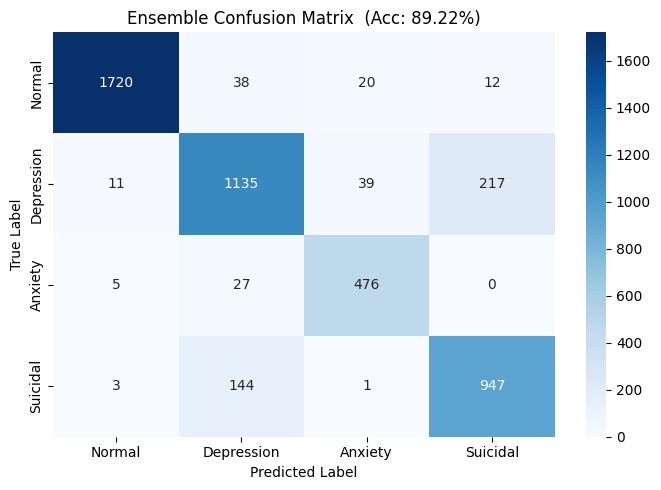

💾 Saved → ensemble_confusion_matrix.png


In [15]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7.5: Ensemble Evaluation — Average Accuracy & Full Report
#--------------------------------------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

LABELS = ['Normal', 'Depression', 'Anxiety', 'Suicidal']

def evaluate_ensemble(model_a, model_b, val_loader_a, val_loader_b, alpha=BEST_ALPHA):
    model_a.eval()
    model_b.eval()
    all_preds, all_labels = [], []

    print("⏳ Running ensemble evaluation on validation set...")
    with torch.no_grad():
        for batch_a, batch_b in tqdm(zip(val_loader_a, val_loader_b), total=len(val_loader_a)):

            ids_a  = batch_a['input_ids'].to(device)
            mask_a = batch_a['attention_mask'].to(device)
            ids_b  = batch_b['input_ids'].to(device)
            mask_b = batch_b['attention_mask'].to(device)
            labels = batch_a['labels']              # ground truth is same for both

            prob_a = F.softmax(model_a(ids_a, mask_a), dim=1)
            prob_b = F.softmax(model_b(ids_b, mask_b), dim=1)

            fused  = alpha * prob_a + (1 - alpha) * prob_b   # ✅ uses learned alpha
            preds  = torch.argmax(fused, dim=1).cpu().tolist()

            all_preds.extend(preds)
            all_labels.extend(labels.tolist())

    # ── 1. Overall Accuracy ──────────────────────────────────────────────
    overall_acc = accuracy_score(all_labels, all_preds)
    macro_f1    = f1_score(all_labels, all_preds, average='macro')

    print("\n" + "═"*55)
    print("       🧠 ENSEMBLE EVALUATION RESULTS")
    print("═"*55)
    print(f"  ✅ Overall Accuracy : {overall_acc * 100:.2f}%")
    print(f"  ✅ Macro F1 Score   : {macro_f1 * 100:.2f}%")

    # ── 2. Per-class Accuracy ────────────────────────────────────────────
    cm        = confusion_matrix(all_labels, all_preds)
    per_class = cm.diagonal() / cm.sum(axis=1)

    print("\n  📊 Per-Class Accuracy:")
    for lbl, acc in zip(LABELS, per_class):
        bar = "█" * int(acc * 20)
        print(f"    {lbl:<12} {acc*100:5.1f}%  {bar}")

    # ── 3. Full Classification Report ────────────────────────────────────
    print("\n  📋 Full Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=LABELS))
    print("═"*55)

    # ── 4. Confusion Matrix Plot ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Ensemble Confusion Matrix  (Acc: {overall_acc*100:.2f}%)")
    plt.tight_layout()
    plt.savefig("ensemble_confusion_matrix.png", dpi=150)
    plt.show()
    print("💾 Saved → ensemble_confusion_matrix.png")

    return overall_acc, macro_f1


# ── LOAD & RUN ───────────────────────────────────────────────────────────
try:
    eval_deb = MentalHealthClassifier(config.DEBERTA_NAME, 4).to(device)           # ✅
    eval_deb.load_state_dict(torch.load('best_deberta.bin', map_location=device))  # ✅

    eval_rob = MentalHealthClassifier(config.MENTAL_ROB_NAME, 4, token=token).to(device)
    eval_rob.load_state_dict(torch.load('best_mental_rob.bin', map_location=device))

    print("✅ Weights loaded. Starting evaluation...\n")
    overall_acc, macro_f1 = evaluate_ensemble(
        eval_deb, eval_rob,
        val_loader_deb, val_loader_rob   # ✅ correct loaders
    )

except FileNotFoundError as e:
    print(f"❌ Model file not found: {e}")
    print("   → Please complete Module 6 (training) first.")
except NameError as e:
    print(f"❌ Missing variable: {e}")
    print("   → Re-run Modules 1–5 before this cell.")

In [19]:
#-------------------------------------------------------------------------
# MODULE 8: Unified Ensemble Demo (DeBERTa + Mental-RoBERTa)
#-------------------------------------------------------------------------
import torch, torch.nn as nn, torch.nn.functional as F
import gradio as gr
from transformers import AutoTokenizer, AutoModel

# 1. Re-define Architecture (must match Module 4 exactly)
class MentalHealthClassifier(nn.Module):
    def __init__(self, model_name, n_classes, token=None):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(
            model_name, token=token,
            trust_remote_code=True, ignore_mismatched_sizes=True
        )
        hidden_size = self.transformer.config.hidden_size
        self.attention_pool = nn.Linear(hidden_size, 1)
        self.drop           = nn.Dropout(0.2)
        self.norm           = nn.LayerNorm(hidden_size * 2)
        self.classifier     = nn.Sequential(
            nn.Linear(hidden_size * 2, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, n_classes)
        )

    def forward(self, input_ids, attention_mask):
        out          = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        seq          = out.last_hidden_state.float()
        cls_out      = seq[:, 0, :]
        attn_weights = self.attention_pool(seq).squeeze(-1)
        attn_weights = attn_weights.masked_fill(attention_mask == 0, -1e9)
        attn_weights = torch.softmax(attn_weights, dim=-1).unsqueeze(-1)
        attn_pool    = (seq * attn_weights).sum(dim=1)
        pooled       = torch.cat([cls_out, attn_pool], dim=-1)
        return self.classifier(self.norm(self.drop(pooled)))

# 2. Device & Token
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
token  = hf_token if 'hf_token' in globals() else None

# 3. Load Models
try:
    model_deb = MentalHealthClassifier("microsoft/deberta-v3-base", 4).to(device)
    model_deb.load_state_dict(torch.load('best_deberta.bin', map_location=device))

    model_rob = MentalHealthClassifier("mental/mental-roberta-base", 4, token=token).to(device)
    model_rob.load_state_dict(torch.load('best_mental_rob.bin', map_location=device))

    model_deb.eval(); model_rob.eval()
    print("🚀 Ensemble Online: DeBERTa + Mental-RoBERTa loaded.")
except Exception as e:
    print(f"❌ Load error: {e}")

# 4. Tokenizers
tokenizer_deb = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
tokenizer_rob = AutoTokenizer.from_pretrained("mental/mental-roberta-base", token=token)

# 5. Prediction Logic
LABELS     = ['Normal', 'Depression', 'Anxiety', 'Suicidal']
BEST_ALPHA = BEST_ALPHA if 'BEST_ALPHA' in globals() else 0.5  # fallback if Module 7 wasn't run

def predict_ensemble(text):
    try:
        with torch.no_grad():
            enc_a  = tokenizer_deb(text, return_tensors='pt', padding=True,
                                   truncation=True, max_length=256).to(device)
            prob_a = F.softmax(model_deb(enc_a['input_ids'], enc_a['attention_mask']), dim=1)

            enc_b  = tokenizer_rob(text, return_tensors='pt', padding=True,
                                   truncation=True, max_length=256).to(device)
            prob_b = F.softmax(model_rob(enc_b['input_ids'], enc_b['attention_mask']), dim=1)

            fused  = BEST_ALPHA * prob_a + (1 - BEST_ALPHA) * prob_b
            fused  = fused.flatten()

        return {LABELS[i]: float(fused[i]) for i in range(len(LABELS))}

    except Exception as e:
        # This surfaces the real error inside Gradio instead of just "Error"
        return f"Runtime Error: {str(e)}"

# 6. Launch
demo = gr.Interface(
    fn=predict_ensemble,
    inputs=gr.Textbox(lines=4, label="User Input"),
    outputs=gr.Label(num_top_classes=4, label="Ensemble Confidence"),
    title="🧠 DeBERTa + Mental-RoBERTa Mental Health Detector",
    theme="soft"
)
demo.launch(share=True)

Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Ensemble Online: DeBERTa + Mental-RoBERTa loaded.


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://4e6e7aae513bd84f67.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [20]:
# Run this to confirm data integrity
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"Number of overlapping samples: {len(overlap)}")

Number of overlapping samples: 0
